# 🔬 Preprocessing Data Makroekonomi
## Analisis Deteksi Anomali Makroekonomi — Early Warning System Krisis Ekonomi

**Tahapan Preprocessing:**
1. Import Library & Load Data
2. Eksplorasi Awal (EDA Ringkas)
3. Penanganan Missing Value
4. Analisis Distribusi Data & Normalisasi
5. Deteksi dan Penanganan Outlier
6. Cek Keseimbangan Data (Labeling + SMOTE/Oversampling)
7. Korelasi Antar Fitur
8. Simpan Data Bersih

---

## 1. Import Library & Load Data

In [4]:
# Install dependencies jika belum tersedia
# !pip install pandas numpy matplotlib seaborn scipy scikit-learn imbalanced-learn

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.impute import KNNImputer
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print('✅ Library berhasil dimuat.')

✅ Library berhasil dimuat.


In [6]:
# Load dataset
df = pd.read_csv('data_before clean.csv')
print(f'Shape: {df.shape}')
print(f'Jumlah negara: {df["economy"].nunique()}')
print(f'Rentang tahun: {df["year"].min()} - {df["year"].max()}')
df.head(10)

Shape: (1715, 16)
Jumlah negara: 49
Rentang tahun: 1990 - 2024


,economy,year,GDP_Growth,GDP_PerCapita_Growth,Inflation_CPI,Total_Reserves,Unemployment,Current_Account_GDP,Trade_GDP,FDI_Inflows_GDP,Exports_GDP,Imports_GDP,Gross_Savings_GDP,Exchange_Rate,Manufacturing_Value,Investment_GDP
0,ARE,1990,18.327986,11.572665,NaN,4.890565e+09,NaN,NaN,NaN,-0.228435,NaN,NaN,NaN,3.671000,7.493889,NaN
1,ARE,1991,0.860082,-4.588785,NaN,5.646814e+09,1.629,NaN,NaN,0.050318,NaN,NaN,NaN,3.671000,7.423064,NaN
2,ARE,1992,3.344945,-1.938000,NaN,5.977161e+09,1.715,NaN,NaN,0.239163,NaN,NaN,NaN,3.671000,7.583672,NaN
3,ARE,1993,1.261191,-3.631361,NaN,6.415332e+09,1.901,NaN,NaN,0.721472,NaN,NaN,NaN,3.671000,7.843781,NaN
4,ARE,1994,6.896149,2.024915,NaN,6.963510e+09,1.834,NaN,NaN,0.105320,NaN,NaN,NaN,3.671000,6.587693,NaN
5,ARE,1995,6.687886,2.022152,NaN,7.778376e+09,1.800,NaN,NaN,0.608195,NaN,NaN,NaN,3.671000,6.772463,NaN
6,ARE,1996,5.798404,-0.836571,NaN,8.350159e+09,1.836,NaN,NaN,0.408475,NaN,NaN,NaN,3.671000,6.637293,NaN
7,ARE,1997,8.190399,-0.251832,NaN,8.603051e+09,1.906,NaN,NaN,0.294816,NaN,NaN,NaN,3.671125,7.895501,NaN
8,ARE,1998,0.291994,-7.064295,NaN,9.305872e+09,2.068,NaN,NaN,0.340485,NaN,NaN,NaN,3.672500,8.631087,NaN
9,ARE,1999,2.902214,-4.205392,NaN,1.079030e+10,2.195,NaN,NaN,-1.166836,NaN,NaN,NaN,3.672500,8.557490,NaN


## 2. Eksplorasi Awal (EDA Ringkas)

In [7]:
# Info tipe data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1715 entries, 0 to 1714
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   economy               1715 non-null   str    
 1   year                  1715 non-null   int64  
 2   GDP_Growth            1712 non-null   float64
 3   GDP_PerCapita_Growth  1712 non-null   float64
 4   Inflation_CPI         1657 non-null   float64
 5   Total_Reserves        1704 non-null   float64
 6   Unemployment          1666 non-null   float64
 7   Current_Account_GDP   1610 non-null   float64
 8   Trade_GDP             1657 non-null   float64
 9   FDI_Inflows_GDP       1710 non-null   float64
 10  Exports_GDP           1657 non-null   float64
 11  Imports_GDP           1657 non-null   float64
 12  Gross_Savings_GDP     1563 non-null   float64
 13  Exchange_Rate         1706 non-null   float64
 14  Manufacturing_Value   1596 non-null   float64
 15  Investment_GDP        1652 non-n

In [8]:
# Statistik deskriptif
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
year,1715.0,2.007000e+03,1.010200e+01,1.990000e+03,1.998000e+03,2.007000e+03,2.016000e+03,2.024000e+03
GDP_Growth,1712.0,3.241000e+00,3.680000e+00,-1.453100e+01,1.470000e+00,3.246000e+00,5.307000e+00,2.462400e+01
GDP_PerCapita_Growth,1712.0,2.107000e+00,3.615000e+00,-1.461400e+01,5.510000e-01,2.137000e+00,4.203000e+00,2.345200e+01
Inflation_CPI,1657.0,1.803500e+01,2.130210e+02,-4.448000e+00,1.813000e+00,3.365000e+00,6.927000e+00,7.481664e+03
Total_Reserves,1704.0,1.328987e+11,3.656005e+11,7.954925e+07,1.491399e+10,3.812125e+10,9.807889e+10,3.900039e+12
Unemployment,1666.0,6.770000e+00,4.650000e+00,2.490000e-01,3.737000e+00,5.555000e+00,8.424000e+00,3.400700e+01
Current_Account_GDP,1610.0,2.490000e-01,5.801000e+00,-2.080500e+01,-3.157000e+00,-6.970000e-01,2.475000e+00,2.884700e+01
Trade_GDP,1657.0,7.656100e+01,5.758700e+01,1.375300e+01,4.283200e+01,5.918000e+01,8.639100e+01,4.373270e+02
FDI_Inflows_GDP,1710.0,3.336000e+00,7.319000e+00,-4.010800e+01,8.330000e-01,1.989000e+00,3.673000e+00,1.056360e+02
Exports_GDP,1657.0,3.905700e+01,3.138000e+01,5.908000e+00,2.078000e+01,2.938800e+01,4.482600e+01,2.289940e+02


In [9]:
# Daftar fitur numerik (exclude economy & year)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c != 'year']
print(f'Fitur numerik ({len(feature_cols)}): {feature_cols}')

Fitur numerik (14): ['GDP_Growth', 'GDP_PerCapita_Growth', 'Inflation_CPI', 'Total_Reserves', 'Unemployment', 'Current_Account_GDP', 'Trade_GDP', 'FDI_Inflows_GDP', 'Exports_GDP', 'Imports_GDP', 'Gross_Savings_GDP', 'Exchange_Rate', 'Manufacturing_Value', 'Investment_GDP']


In [10]:
# Daftar negara dalam dataset
economies = sorted(df['economy'].unique())
print(f'\nDaftar {len(economies)} negara/ekonomi:')
print(economies)


Daftar 49 negara/ekonomi:
['ARE', 'ARG', 'AUS', 'AUT', 'BEL', 'BGD', 'BRA', 'CAN', 'CHE', 'CHL', 'CHN', 'COL', 'CZE', 'DEU', 'EGY', 'ESP', 'FRA', 'GBR', 'GRC', 'HUN', 'IDN', 'IND', 'IRL', 'ITA', 'JPN', 'KEN', 'KOR', 'LKA', 'MEX', 'MYS', 'NGA', 'NLD', 'NOR', 'NZL', 'PAK', 'PER', 'PHL', 'POL', 'PRT', 'ROU', 'RUS', 'SAU', 'SGP', 'SWE', 'THA', 'TUR', 'USA', 'VNM', 'ZAF']


---
## 3. Penanganan Missing Value

### 3.1 Identifikasi Missing Value

In [11]:
# Hitung missing value per kolom
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print('='*50)
print('RINGKASAN MISSING VALUE')
print('='*50)
print(missing_df[missing_df['Missing Count'] > 0])
print(f'\nTotal sel missing: {df.isnull().sum().sum()}')
print(f'Total sel: {df.shape[0] * df.shape[1]}')
print(f'Persentase total: {(df.isnull().sum().sum() / (df.shape[0]*df.shape[1]) * 100):.2f}%')

RINGKASAN MISSING VALUE
                      Missing Count  Missing %
Gross_Savings_GDP               152       8.86
Manufacturing_Value             119       6.94
Current_Account_GDP             105       6.12
Investment_GDP                   63       3.67
Trade_GDP                        58       3.38
Inflation_CPI                    58       3.38
Imports_GDP                      58       3.38
Exports_GDP                      58       3.38
Unemployment                     49       2.86
Total_Reserves                   11       0.64
Exchange_Rate                     9       0.52
FDI_Inflows_GDP                   5       0.29
GDP_PerCapita_Growth              3       0.17
GDP_Growth                        3       0.17

Total sel missing: 751
Total sel: 27440
Persentase total: 2.74%


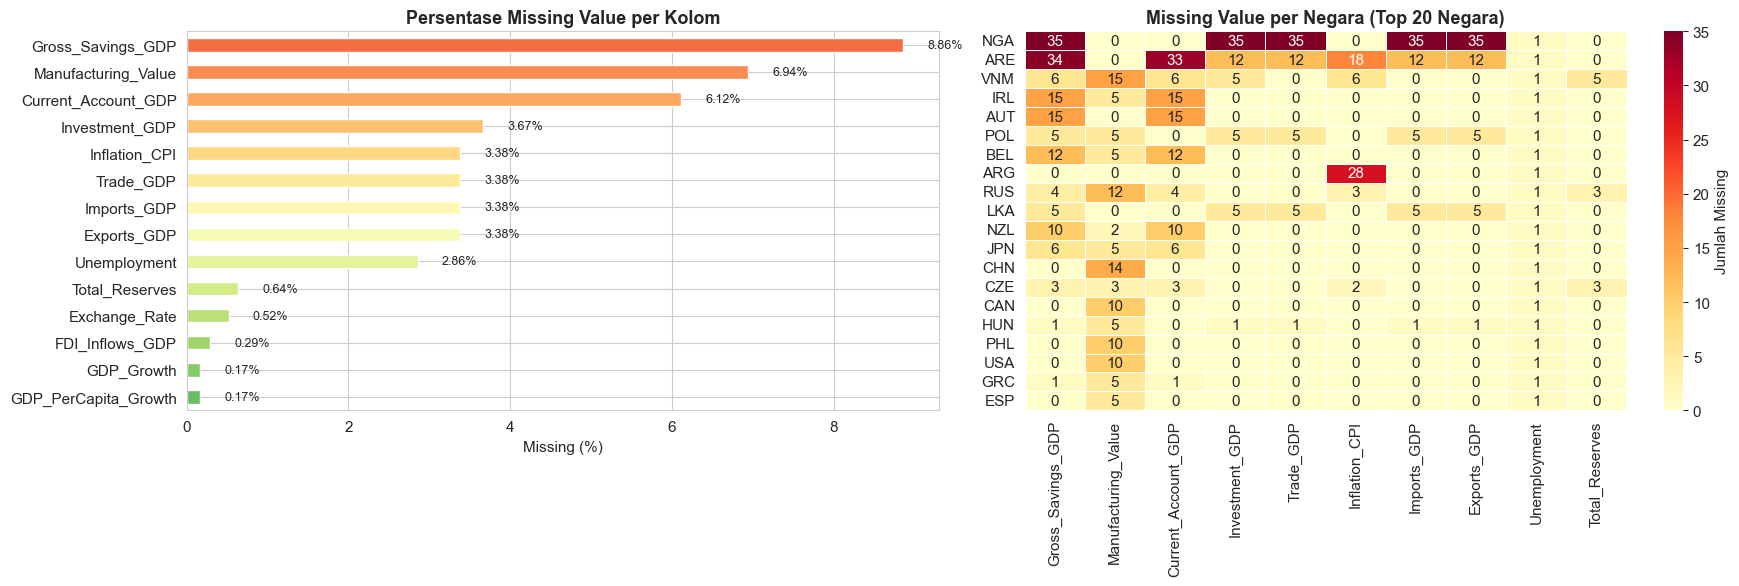

In [12]:
# Visualisasi missing value
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar chart missing
missing_filtered = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %')
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(missing_filtered)))
missing_filtered['Missing %'].plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('Persentase Missing Value per Kolom', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Missing (%)')
for i, (idx, row) in enumerate(missing_filtered.iterrows()):
    axes[0].text(row['Missing %'] + 0.3, i, f"{row['Missing %']}%", va='center', fontsize=9)

# Heatmap missing per negara (top 10 missing columns)
top_missing_cols = missing_df[missing_df['Missing Count'] > 0].head(10).index.tolist()
if top_missing_cols:
    missing_by_country = df.groupby('economy')[top_missing_cols].apply(lambda x: x.isnull().sum())
    # Ambil 20 negara dengan missing terbanyak
    top_countries = missing_by_country.sum(axis=1).nlargest(20).index
    sns.heatmap(missing_by_country.loc[top_countries], cmap='YlOrRd', annot=True, fmt='g',
                linewidths=0.5, ax=axes[1], cbar_kws={'label': 'Jumlah Missing'})
    axes[1].set_title('Missing Value per Negara (Top 20 Negara)', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

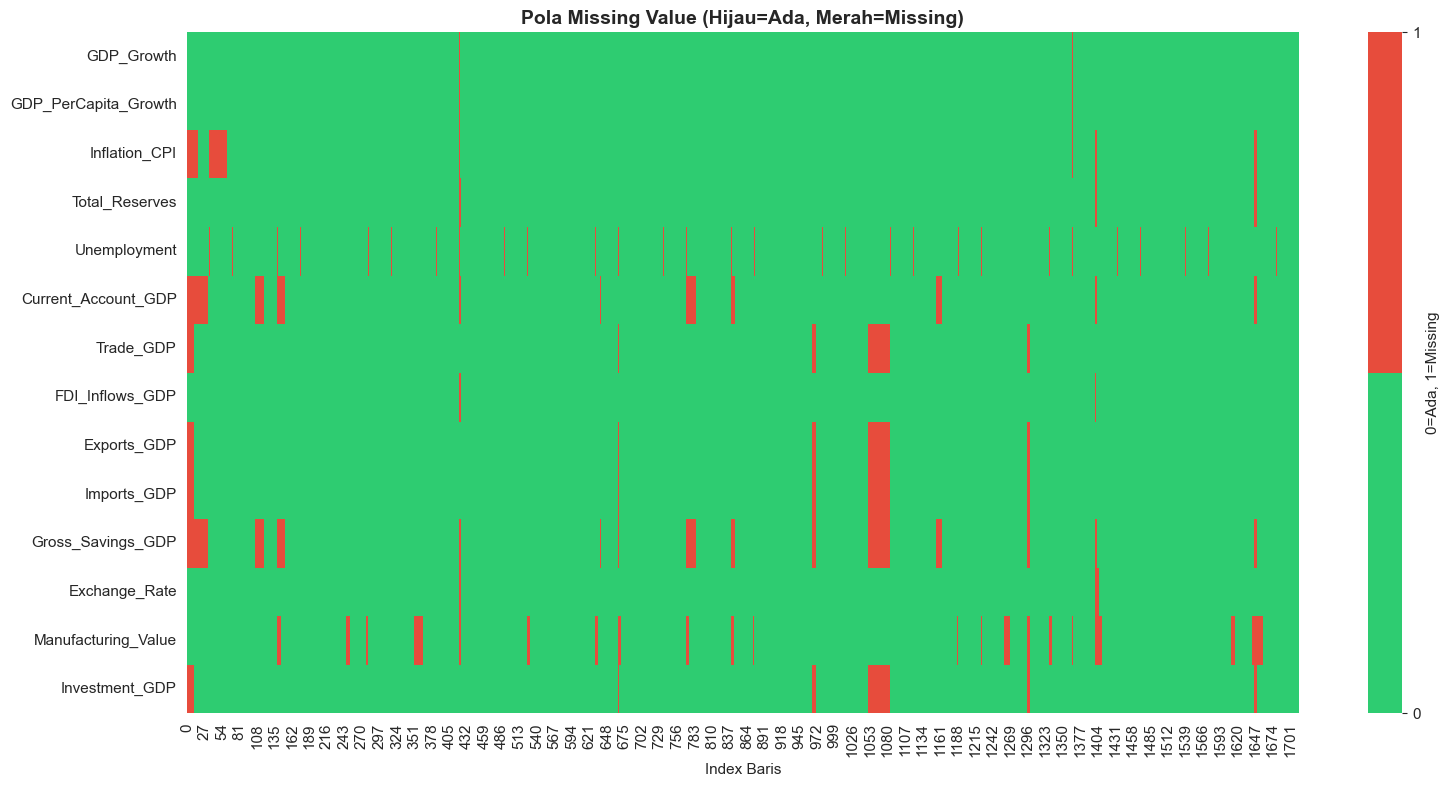

In [13]:
# Visualisasi pattern missing value (msno-style)
fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(df[feature_cols].isnull().T, cbar=True, yticklabels=True,
            cmap=['#2ecc71', '#e74c3c'], ax=ax,
            cbar_kws={'label': '0=Ada, 1=Missing', 'ticks': [0, 1]})
ax.set_title('Pola Missing Value (Hijau=Ada, Merah=Missing)', fontsize=14, fontweight='bold')
ax.set_xlabel('Index Baris')
plt.tight_layout()
plt.show()

### 3.2 Strategi Penanganan Missing Value

Strategi yang digunakan:
1. **Kolom dengan missing > 50%**: Pertimbangkan drop atau imputasi khusus
2. **Data time-series per negara**: Gunakan interpolasi linear (forward/backward fill) per negara — karena data makroekonomi bersifat temporal
3. **Sisa missing**: Gunakan KNN Imputer untuk menangkap pola antar fitur
4. **Baris yang masih memiliki terlalu banyak missing** setelah imputasi: Drop

In [14]:
# --- Step 1: Drop baris yang terlalu banyak missing (> 70% fitur kosong) ---
threshold = 0.7
n_features = len(feature_cols)
mask_too_many_missing = df[feature_cols].isnull().sum(axis=1) > (threshold * n_features)
print(f'Baris dengan > {threshold*100:.0f}% fitur missing: {mask_too_many_missing.sum()}')

df_clean = df[~mask_too_many_missing].copy()
print(f'Shape setelah drop baris terlalu banyak missing: {df_clean.shape}')

Baris dengan > 70% fitur missing: 1
Shape setelah drop baris terlalu banyak missing: (1714, 16)


In [15]:
# --- Step 2: Interpolasi per negara (time-series) ---
# Karena data makroekonomi bersifat sekuensial per negara per tahun,
# interpolasi linear adalah metode yang paling tepat.

df_clean = df_clean.sort_values(['economy', 'year']).reset_index(drop=True)

for col in feature_cols:
    df_clean[col] = df_clean.groupby('economy')[col].transform(
        lambda x: x.interpolate(method='linear', limit_direction='both')
    )

missing_after_interp = df_clean[feature_cols].isnull().sum()
print('Missing setelah interpolasi per negara:')
print(missing_after_interp[missing_after_interp > 0])
print(f'\nTotal missing tersisa: {missing_after_interp.sum()}')

Missing setelah interpolasi per negara:
Trade_GDP            35
Exports_GDP          35
Imports_GDP          35
Gross_Savings_GDP    35
Investment_GDP       35
dtype: int64

Total missing tersisa: 175


In [16]:
# --- Step 3: KNN Imputer untuk sisa missing ---
remaining_missing = df_clean[feature_cols].isnull().sum().sum()

if remaining_missing > 0:
    print(f'Sisa missing: {remaining_missing} → Menggunakan KNN Imputer (k=5)...')
    imputer = KNNImputer(n_neighbors=5, weights='distance')
    df_clean[feature_cols] = imputer.fit_transform(df_clean[feature_cols])
    print(f'Missing setelah KNN Imputer: {df_clean[feature_cols].isnull().sum().sum()}')
else:
    print('✅ Tidak ada missing value tersisa setelah interpolasi.')

Sisa missing: 175 → Menggunakan KNN Imputer (k=5)...
Missing setelah KNN Imputer: 0


In [17]:
# Verifikasi akhir missing value
print('='*50)
print('VERIFIKASI AKHIR MISSING VALUE')
print('='*50)
print(f'Total missing: {df_clean.isnull().sum().sum()}')
print(f'Shape data: {df_clean.shape}')
print(f'\n✅ Missing value telah ditangani sepenuhnya.' if df_clean.isnull().sum().sum() == 0 else '⚠️ Masih ada missing value.')

VERIFIKASI AKHIR MISSING VALUE
Total missing: 0
Shape data: (1714, 16)

✅ Missing value telah ditangani sepenuhnya.


---
## 4. Analisis Distribusi Data & Normalisasi

### 4.1 Distribusi Sebelum Normalisasi

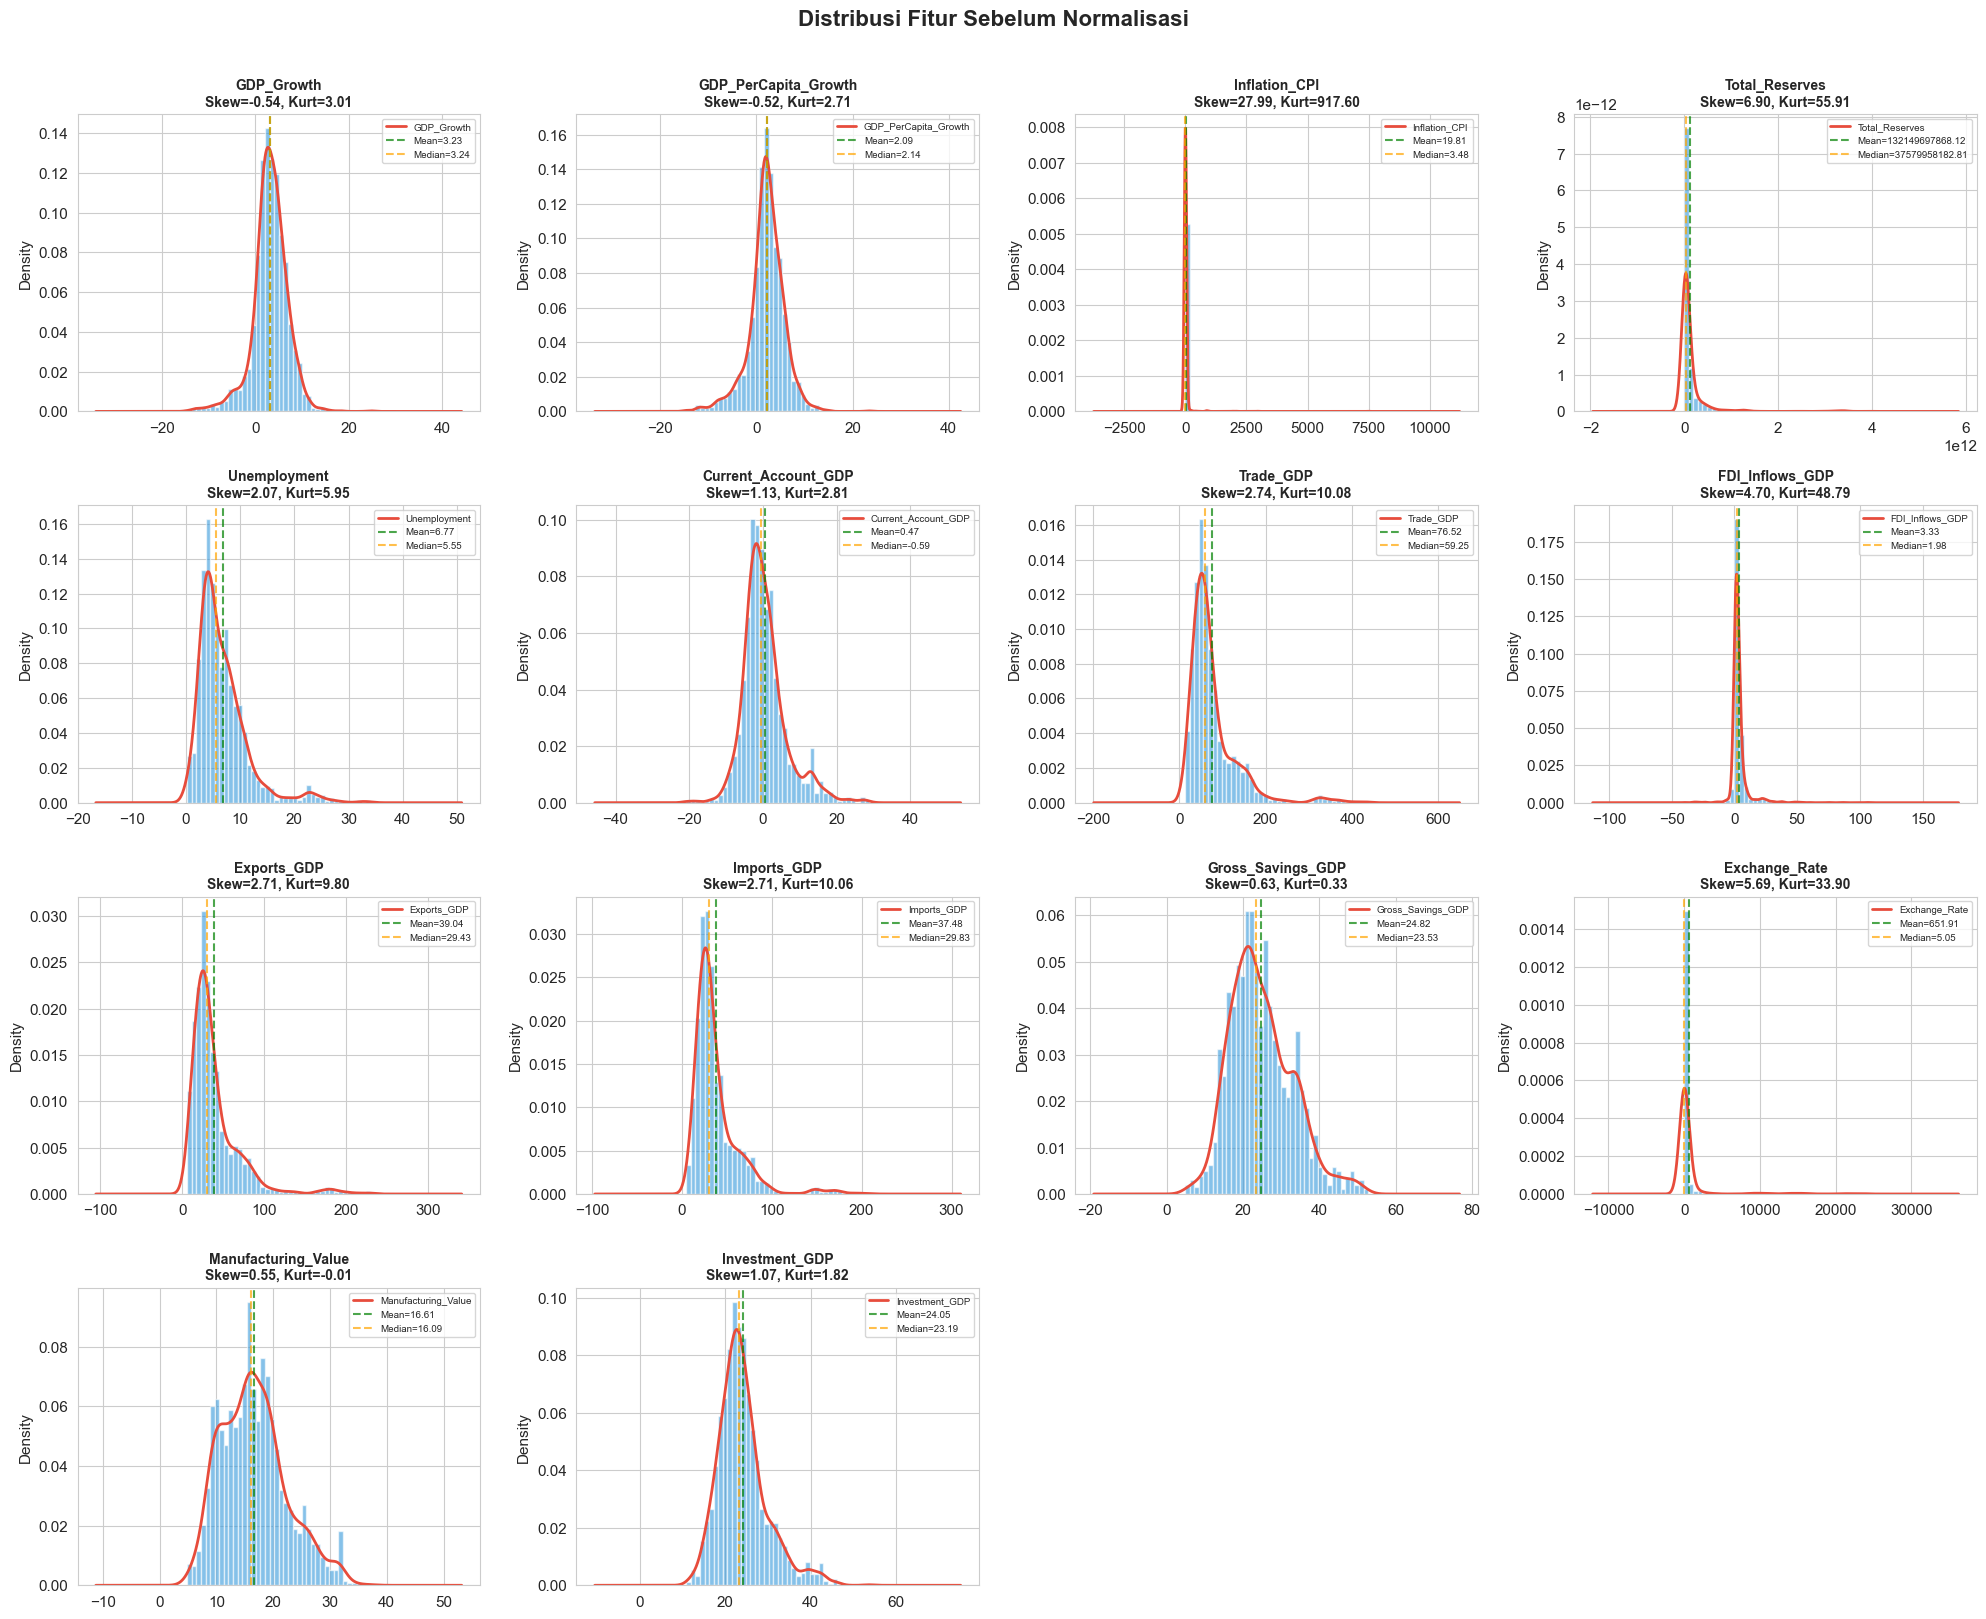

In [18]:
# Histogram distribusi setiap fitur
n_cols = 4
n_rows = int(np.ceil(len(feature_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows*4))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    data = df_clean[col].dropna()
    
    # Histogram + KDE
    ax.hist(data, bins=40, alpha=0.6, color='#3498db', edgecolor='white', density=True)
    data.plot.kde(ax=ax, color='#e74c3c', linewidth=2)
    
    # Statistik
    skewness = data.skew()
    kurtosis = data.kurtosis()
    ax.set_title(f'{col}\nSkew={skewness:.2f}, Kurt={kurtosis:.2f}', fontsize=10, fontweight='bold')
    ax.axvline(data.mean(), color='green', linestyle='--', alpha=0.7, label=f'Mean={data.mean():.2f}')
    ax.axvline(data.median(), color='orange', linestyle='--', alpha=0.7, label=f'Median={data.median():.2f}')
    ax.legend(fontsize=7)

# Kosongkan axes yang tidak terpakai
for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur Sebelum Normalisasi', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [19]:
# Ringkasan skewness & kurtosis
skew_kurt = pd.DataFrame({
    'Skewness': df_clean[feature_cols].skew(),
    'Kurtosis': df_clean[feature_cols].kurtosis(),
    'Mean': df_clean[feature_cols].mean(),
    'Std': df_clean[feature_cols].std(),
    'Min': df_clean[feature_cols].min(),
    'Max': df_clean[feature_cols].max()
}).round(3)

# Interpretasi skewness
def interpret_skew(s):
    if abs(s) < 0.5: return '✅ Simetris'
    elif abs(s) < 1: return '⚠️ Agak Miring'
    else: return '❌ Sangat Miring'

skew_kurt['Interpretasi'] = skew_kurt['Skewness'].apply(interpret_skew)
print('Analisis Distribusi:')
skew_kurt

Analisis Distribusi:


,Skewness,Kurtosis,Mean,Std,Min,Max,Interpretasi
GDP_Growth,-0.542,3.015,3.226000e+00,3.707000e+00,-1.453100e+01,2.462400e+01,⚠️ Agak Miring
GDP_PerCapita_Growth,-0.520,2.713,2.093000e+00,3.636000e+00,-1.461400e+01,2.345200e+01,⚠️ Agak Miring
Inflation_CPI,27.988,917.600,1.981500e+01,2.125570e+02,-4.448000e+00,7.481664e+03,❌ Sangat Miring
Total_Reserves,6.904,55.914,1.321497e+11,3.646631e+11,7.954925e+07,3.900039e+12,❌ Sangat Miring
Unemployment,2.068,5.947,6.766000e+00,4.646000e+00,2.490000e-01,3.400700e+01,❌ Sangat Miring
Current_Account_GDP,1.131,2.808,4.670000e-01,5.948000e+00,-2.080500e+01,2.884700e+01,❌ Sangat Miring
Trade_GDP,2.739,10.083,7.651700e+01,5.691900e+01,1.375300e+01,4.373270e+02,❌ Sangat Miring
FDI_Inflows_GDP,4.695,48.787,3.331000e+00,7.312000e+00,-4.010800e+01,1.056360e+02,❌ Sangat Miring
Exports_GDP,2.713,9.797,3.903600e+01,3.102600e+01,5.908000e+00,2.289940e+02,❌ Sangat Miring
Imports_GDP,2.706,10.060,3.748100e+01,2.620400e+01,4.631000e+00,2.083330e+02,❌ Sangat Miring


In [20]:
# Shapiro-Wilk Test untuk normalitas (sampel max 5000)
print('='*60)
print('UJI NORMALITAS (Shapiro-Wilk Test, α=0.05)')
print('='*60)
normality_results = []
for col in feature_cols:
    data = df_clean[col].dropna()
    sample = data.sample(min(len(data), 5000), random_state=42)
    stat, p_value = stats.shapiro(sample)
    is_normal = 'Ya' if p_value > 0.05 else 'Tidak'
    normality_results.append({'Fitur': col, 'Statistic': round(stat, 4),
                               'P-Value': f'{p_value:.6f}', 'Normal?': is_normal})

normality_df = pd.DataFrame(normality_results)
print(normality_df.to_string(index=False))
print(f"\nFitur normal: {normality_df[normality_df['Normal?']=='Ya'].shape[0]}/{len(feature_cols)}")

UJI NORMALITAS (Shapiro-Wilk Test, α=0.05)
               Fitur  Statistic  P-Value Normal?
          GDP_Growth     0.9562 0.000000   Tidak
GDP_PerCapita_Growth     0.9581 0.000000   Tidak
       Inflation_CPI     0.0486 0.000000   Tidak
      Total_Reserves     0.3260 0.000000   Tidak
        Unemployment     0.8243 0.000000   Tidak
 Current_Account_GDP     0.9238 0.000000   Tidak
           Trade_GDP     0.7349 0.000000   Tidak
     FDI_Inflows_GDP     0.5103 0.000000   Tidak
         Exports_GDP     0.7353 0.000000   Tidak
         Imports_GDP     0.7451 0.000000   Tidak
   Gross_Savings_GDP     0.9735 0.000000   Tidak
       Exchange_Rate     0.2333 0.000000   Tidak
 Manufacturing_Value     0.9750 0.000000   Tidak
      Investment_GDP     0.9405 0.000000   Tidak

Fitur normal: 0/14


### 4.2 Normalisasi/Standarisasi

**Strategi:**
- Karena data makroekonomi mengandung outlier dan distribusi skewed, kita menggunakan **RobustScaler** sebagai metode utama (robust terhadap outlier).
- Kita juga menyimpan versi **StandardScaler** dan **MinMaxScaler** untuk perbandingan.
- Untuk anomaly detection (Isolation Forest, LOF, Autoencoder), **StandardScaler** umumnya lebih cocok.

In [21]:
# Terapkan beberapa scaler untuk perbandingan
scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}

scaled_data = {}
for name, scaler in scalers.items():
    scaled_data[name] = pd.DataFrame(
        scaler.fit_transform(df_clean[feature_cols]),
        columns=feature_cols,
        index=df_clean.index
    )
    print(f'{name}: min={scaled_data[name].min().min():.3f}, max={scaled_data[name].max().max():.3f}')

StandardScaler: min=-5.943, max=35.115
MinMaxScaler: min=0.000, max=1.000
RobustScaler: min=-14.836, max=1306.968


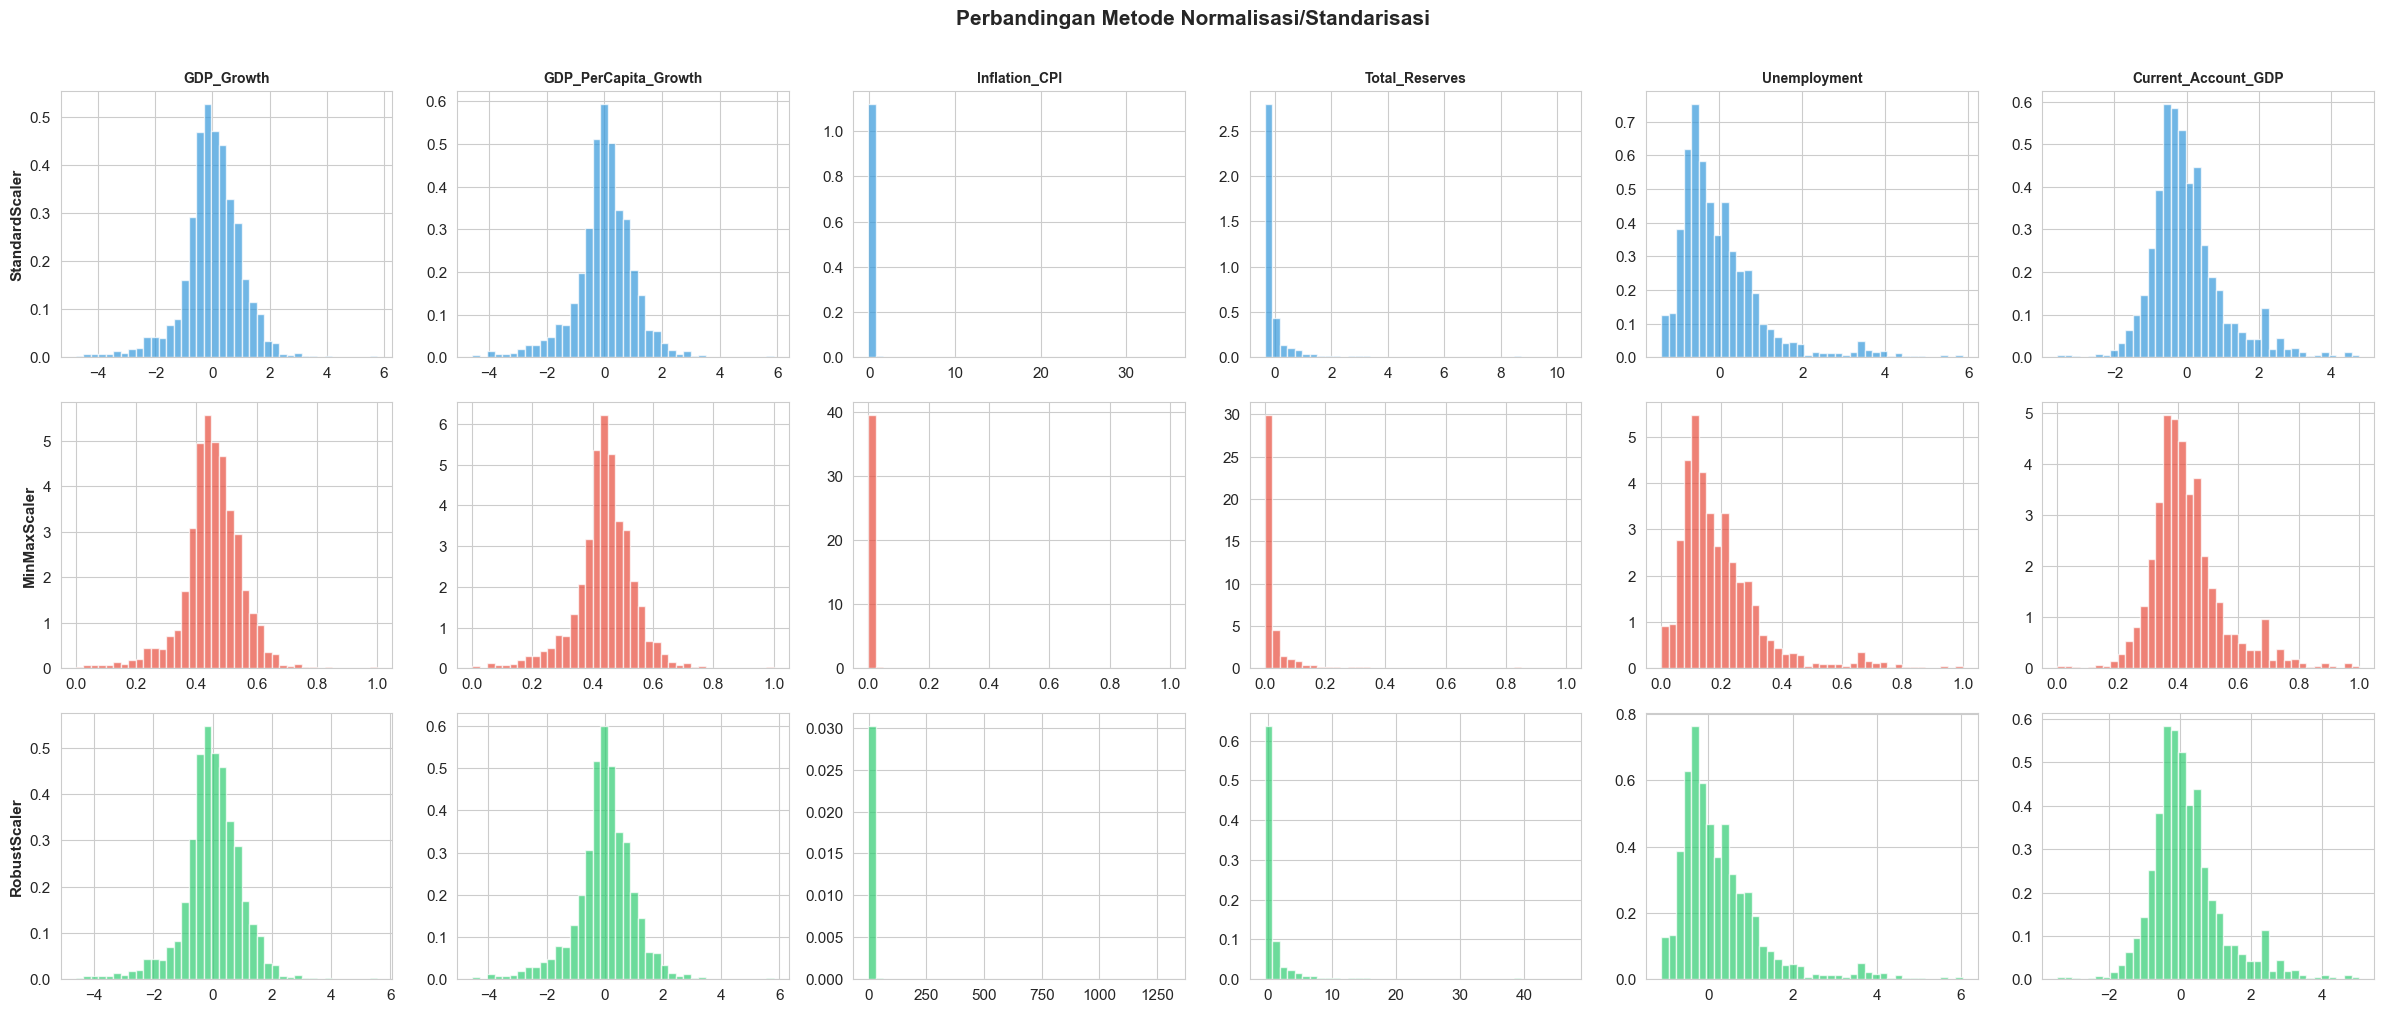

In [22]:
# Visualisasi perbandingan scaler
sample_features = feature_cols[:6]  # Ambil 6 fitur pertama untuk visualisasi

fig, axes = plt.subplots(3, len(sample_features), figsize=(24, 10))

for i, (name, data) in enumerate(scaled_data.items()):
    for j, col in enumerate(sample_features):
        ax = axes[i][j]
        ax.hist(data[col], bins=40, alpha=0.7, color=['#3498db', '#e74c3c', '#2ecc71'][i],
                edgecolor='white', density=True)
        if j == 0:
            ax.set_ylabel(name, fontsize=11, fontweight='bold')
        if i == 0:
            ax.set_title(col, fontsize=10, fontweight='bold')

plt.suptitle('Perbandingan Metode Normalisasi/Standarisasi', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [23]:
# Pilih StandardScaler sebagai metode utama untuk anomaly detection
# Alasan: model Isolation Forest, LOF, dan Autoencoder bekerja optimal dengan data terstandarkan

scaler_main = StandardScaler()
df_clean[feature_cols] = scaler_main.fit_transform(df_clean[feature_cols])

print('✅ Data telah dinormalisasi menggunakan StandardScaler')
print(f'Mean ~ 0: {df_clean[feature_cols].mean().mean():.6f}')
print(f'Std ~ 1: {df_clean[feature_cols].std().mean():.6f}')
df_clean[feature_cols].describe().T.round(3)

✅ Data telah dinormalisasi menggunakan StandardScaler
Mean ~ 0: -0.000000
Std ~ 1: 1.000292


,count,mean,std,min,25%,50%,75%,max
GDP_Growth,1714.0,0.0,1.0,-4.791,-0.477,0.005,0.561,5.774
GDP_PerCapita_Growth,1714.0,-0.0,1.0,-4.596,-0.429,0.012,0.580,5.875
Inflation_CPI,1714.0,-0.0,1.0,-0.114,-0.084,-0.077,-0.058,35.115
Total_Reserves,1714.0,0.0,1.0,-0.362,-0.322,-0.259,-0.095,10.336
Unemployment,1714.0,-0.0,1.0,-1.403,-0.654,-0.261,0.360,5.864
Current_Account_GDP,1714.0,0.0,1.0,-3.577,-0.615,-0.178,0.368,4.773
Trade_GDP,1714.0,0.0,1.0,-1.103,-0.578,-0.303,0.186,6.341
FDI_Inflows_GDP,1714.0,-0.0,1.0,-5.943,-0.342,-0.185,0.046,13.996
Exports_GDP,1714.0,0.0,1.0,-1.068,-0.581,-0.310,0.200,6.124
Imports_GDP,1714.0,-0.0,1.0,-1.254,-0.591,-0.292,0.212,6.522


---
## 5. Deteksi dan Penanganan Outlier

### 5.1 Identifikasi Outlier

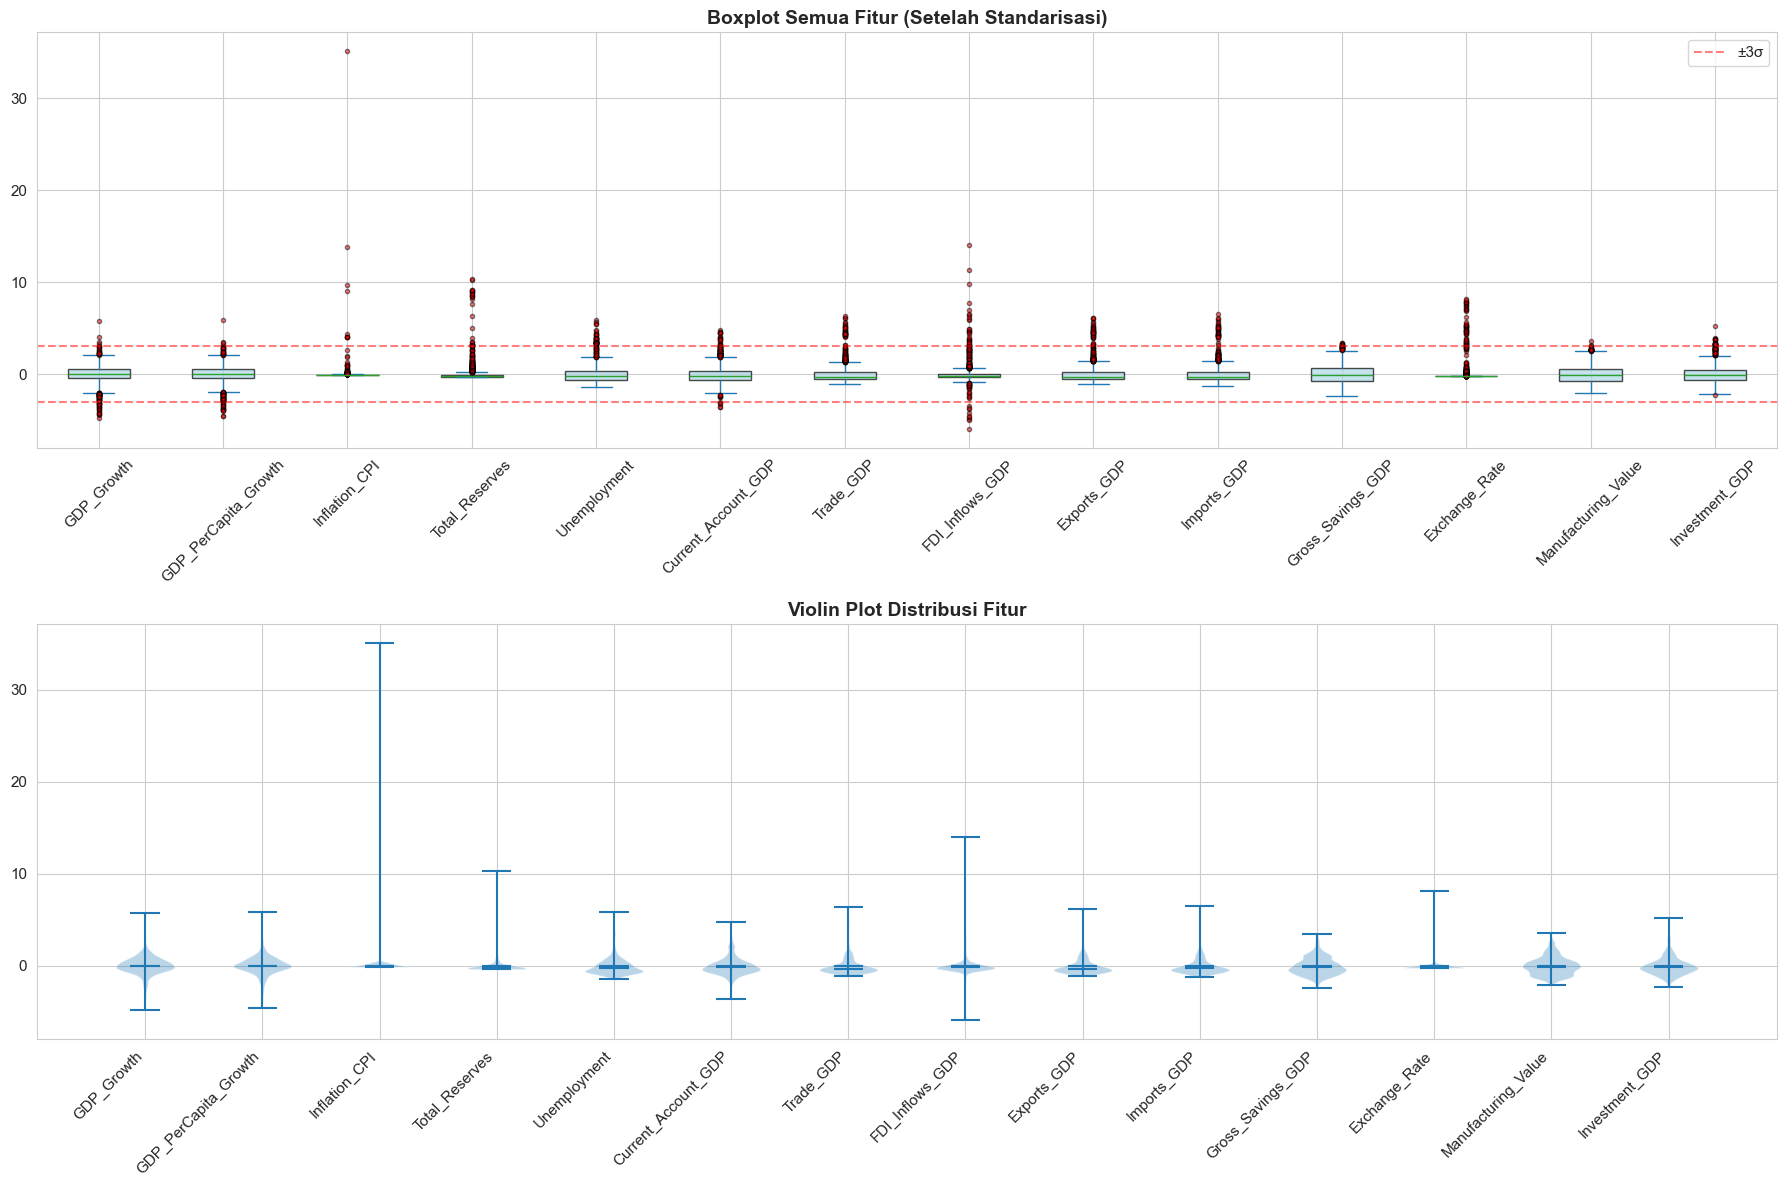

In [24]:
# Box plot untuk identifikasi outlier
fig, axes = plt.subplots(2, 1, figsize=(18, 12))

# Sebelum penanganan
df_clean[feature_cols].plot(kind='box', ax=axes[0], vert=True, patch_artist=True,
                             boxprops=dict(facecolor='lightblue', alpha=0.7),
                             flierprops=dict(marker='o', markerfacecolor='red', markersize=3, alpha=0.5))
axes[0].set_title('Boxplot Semua Fitur (Setelah Standarisasi)', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(y=3, color='red', linestyle='--', alpha=0.5, label='±3σ')
axes[0].axhline(y=-3, color='red', linestyle='--', alpha=0.5)
axes[0].legend()

# Violin plot
parts = axes[1].violinplot([df_clean[col].dropna().values for col in feature_cols],
                           showmeans=True, showmedians=True)
axes[1].set_xticks(range(1, len(feature_cols)+1))
axes[1].set_xticklabels(feature_cols, rotation=45, ha='right')
axes[1].set_title('Violin Plot Distribusi Fitur', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [25]:
# Hitung jumlah outlier dengan IQR method & Z-score method
print('='*70)
print('DETEKSI OUTLIER: IQR Method vs Z-Score Method')
print('='*70)

outlier_summary = []

for col in feature_cols:
    data = df_clean[col].dropna()
    
    # IQR Method
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_iqr = ((data < lower) | (data > upper)).sum()
    
    # Z-Score Method (|z| > 3)
    z_scores = np.abs(stats.zscore(data))
    n_zscore = (z_scores > 3).sum()
    
    outlier_summary.append({
        'Fitur': col,
        'Outlier (IQR)': n_iqr,
        '% IQR': round(n_iqr/len(data)*100, 2),
        'Outlier (Z>3)': n_zscore,
        '% Z-Score': round(n_zscore/len(data)*100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))
print(f'\nTotal outlier (IQR): {outlier_df["Outlier (IQR)"].sum()}')
print(f'Total outlier (Z-Score): {outlier_df["Outlier (Z>3)"].sum()}')

DETEKSI OUTLIER: IQR Method vs Z-Score Method
               Fitur  Outlier (IQR)  % IQR  Outlier (Z>3)  % Z-Score
          GDP_Growth             89   5.19             27       1.58
GDP_PerCapita_Growth             99   5.78             23       1.34
       Inflation_CPI            163   9.51              9       0.53
      Total_Reserves            215  12.54             31       1.81
        Unemployment             81   4.73             50       2.92
 Current_Account_GDP            124   7.23             27       1.58
           Trade_GDP            144   8.40             37       2.16
     FDI_Inflows_GDP            176  10.27             41       2.39
         Exports_GDP            120   7.00             40       2.33
         Imports_GDP            126   7.35             37       2.16
   Gross_Savings_GDP             31   1.81             12       0.70
       Exchange_Rate            264  15.40             53       3.09
 Manufacturing_Value             33   1.93              3

### 5.2 Penanganan Outlier

**Strategi:** Untuk deteksi anomali, **outlier TIDAK dihapus**, karena outlier justru bisa menjadi **indikator krisis/anomali** yang ingin dideteksi.

Namun, kita tetap melakukan **Winsorizing (capping)** pada nilai yang sangat ekstrem (> 5σ) untuk mencegah overfitting pada noise, bukan sinyal krisis.

**Alasan:**
- Inflasi Argentina (`Inflation_CPI` > 200%) atau crash GDP -10% adalah sinyal krisis yang valid
- Nilai > 5σ umumnya merupakan error data atau kejadian sangat langka

In [26]:
# Winsorizing: Cap nilai di luar 5-sigma (persentil 0.5% dan 99.5%)
df_capped = df_clean.copy()
cap_count = 0

for col in feature_cols:
    lower_bound = df_capped[col].quantile(0.005)
    upper_bound = df_capped[col].quantile(0.995)
    
    n_capped = ((df_capped[col] < lower_bound) | (df_capped[col] > upper_bound)).sum()
    cap_count += n_capped
    
    df_capped[col] = df_capped[col].clip(lower=lower_bound, upper=upper_bound)

print(f'Total nilai yang di-cap (winsorized): {cap_count}')
print(f'Persentase: {cap_count / (len(df_capped) * len(feature_cols)) * 100:.2f}%')

Total nilai yang di-cap (winsorized): 252
Persentase: 1.05%


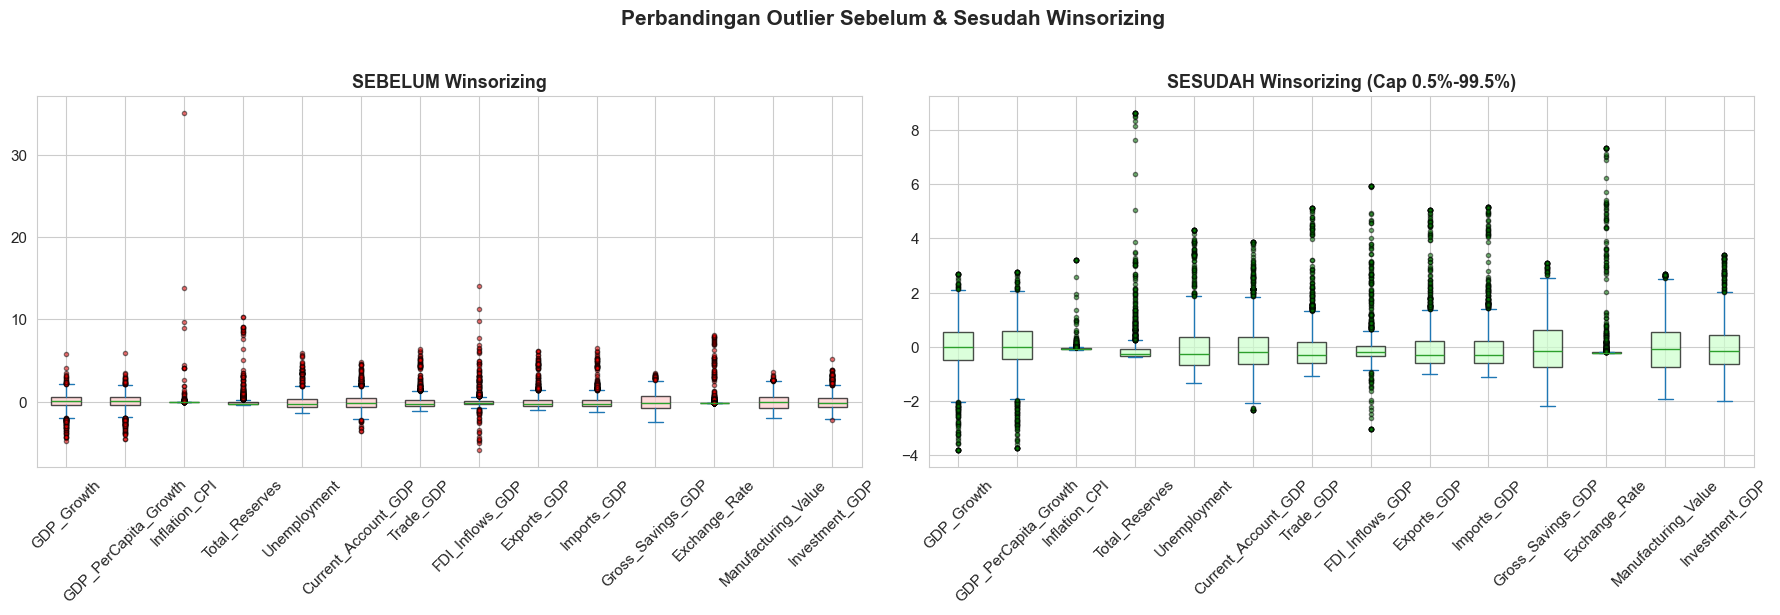

In [27]:
# Visualisasi sebelum vs sesudah capping
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Sebelum
df_clean[feature_cols].plot(kind='box', ax=axes[0], vert=True, patch_artist=True,
                            boxprops=dict(facecolor='#ffcccc', alpha=0.7),
                            flierprops=dict(marker='o', markerfacecolor='red', markersize=3, alpha=0.5))
axes[0].set_title('SEBELUM Winsorizing', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Sesudah
df_capped[feature_cols].plot(kind='box', ax=axes[1], vert=True, patch_artist=True,
                             boxprops=dict(facecolor='#ccffcc', alpha=0.7),
                             flierprops=dict(marker='o', markerfacecolor='green', markersize=3, alpha=0.5))
axes[1].set_title('SESUDAH Winsorizing (Cap 0.5%-99.5%)', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Perbandingan Outlier Sebelum & Sesudah Winsorizing', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Update dataframe utama
df_clean = df_capped.copy()

---
## 6. Cek Keseimbangan Data (Labeling + Resampling)

### 6.1 Membuat Label Anomali (Crisis Label)

Untuk deteksi anomali, kita perlu membuat label krisis berdasarkan indikator makroekonomi.

**Definisi Krisis Ekonomi (Multi-Indikator):**
- GDP Growth < -2% (kontraksi ekonomi signifikan)
- ATAU Inflation CPI > 2σ dari mean (hiperinflasi relatif)
- ATAU Unemployment naik > 1.5σ dari mean negara tersebut
- ATAU Current Account deficit > 2σ

> **Catatan:** Label ini bersifat proxy/heuristik. Untuk riset lebih lanjut, gunakan data krisis historis (Laeven & Valencia, IMF).

In [28]:
# Labeling berbasis rule — menggunakan data sebelum standarisasi
# Kita perlu reload data asli yang sudah dibersihkan missing value tapi belum di-scale

# Re-load dan re-process tanpa scaling untuk labeling
df_label = pd.read_csv('data_before clean.csv')
df_label = df_label.sort_values(['economy', 'year']).reset_index(drop=True)

# Hapus baris terlalu banyak missing
mask_too_many = df_label[feature_cols].isnull().sum(axis=1) > (0.7 * len(feature_cols))
df_label = df_label[~mask_too_many].copy()

# Interpolasi
for col in feature_cols:
    df_label[col] = df_label.groupby('economy')[col].transform(
        lambda x: x.interpolate(method='linear', limit_direction='both')
    )

# KNN Imputer
remaining = df_label[feature_cols].isnull().sum().sum()
if remaining > 0:
    imp = KNNImputer(n_neighbors=5, weights='distance')
    df_label[feature_cols] = imp.fit_transform(df_label[feature_cols])

print(f'Data untuk labeling: {df_label.shape}')
print(f'Missing: {df_label[feature_cols].isnull().sum().sum()}')

Data untuk labeling: (1714, 16)
Missing: 0


In [29]:
# Buat label krisis
def create_crisis_label(df):
    """
    Membuat label krisis berdasarkan beberapa indikator makroekonomi.
    1 = Krisis/Anomali, 0 = Normal
    """
    labels = pd.Series(0, index=df.index)
    
    # Kriteria 1: Kontraksi GDP signifikan (GDP_Growth < -2%)
    if 'GDP_Growth' in df.columns:
        crit_gdp = df['GDP_Growth'] < -2
        labels = labels | crit_gdp.astype(int)
    
    # Kriteria 2: Inflasi sangat tinggi (> mean + 2*std per negara)
    if 'Inflation_CPI' in df.columns:
        inflation_threshold = df.groupby('economy')['Inflation_CPI'].transform(
            lambda x: x.mean() + 2 * x.std()
        )
        crit_inflation = df['Inflation_CPI'] > inflation_threshold
        labels = labels | crit_inflation.astype(int)
    
    # Kriteria 3: Unemployment sangat tinggi (> mean + 1.5*std per negara)
    if 'Unemployment' in df.columns:
        unemp_threshold = df.groupby('economy')['Unemployment'].transform(
            lambda x: x.mean() + 1.5 * x.std()
        )
        crit_unemp = df['Unemployment'] > unemp_threshold
        labels = labels | crit_unemp.astype(int)
    
    # Kriteria 4: Current Account deficit sangat besar (> mean - 2*std)
    if 'Current_Account_GDP' in df.columns:
        ca_threshold = df.groupby('economy')['Current_Account_GDP'].transform(
            lambda x: x.mean() - 2 * x.std()
        )
        crit_ca = df['Current_Account_GDP'] < ca_threshold
        labels = labels | crit_ca.astype(int)
    
    return labels

df_label['crisis_label'] = create_crisis_label(df_label)

# Juga tambahkan ke df_clean
df_clean = df_clean.reset_index(drop=True)
df_label = df_label.reset_index(drop=True)

# Pastikan index cocok
df_clean['crisis_label'] = df_label['crisis_label'].values

print('\n--- Distribusi Label Krisis ---')
print(df_label['crisis_label'].value_counts())
print(f'\nPersentase krisis: {df_label["crisis_label"].mean()*100:.2f}%')


--- Distribusi Label Krisis ---
crisis_label
0    1385
1     329
Name: count, dtype: int64

Persentase krisis: 19.19%


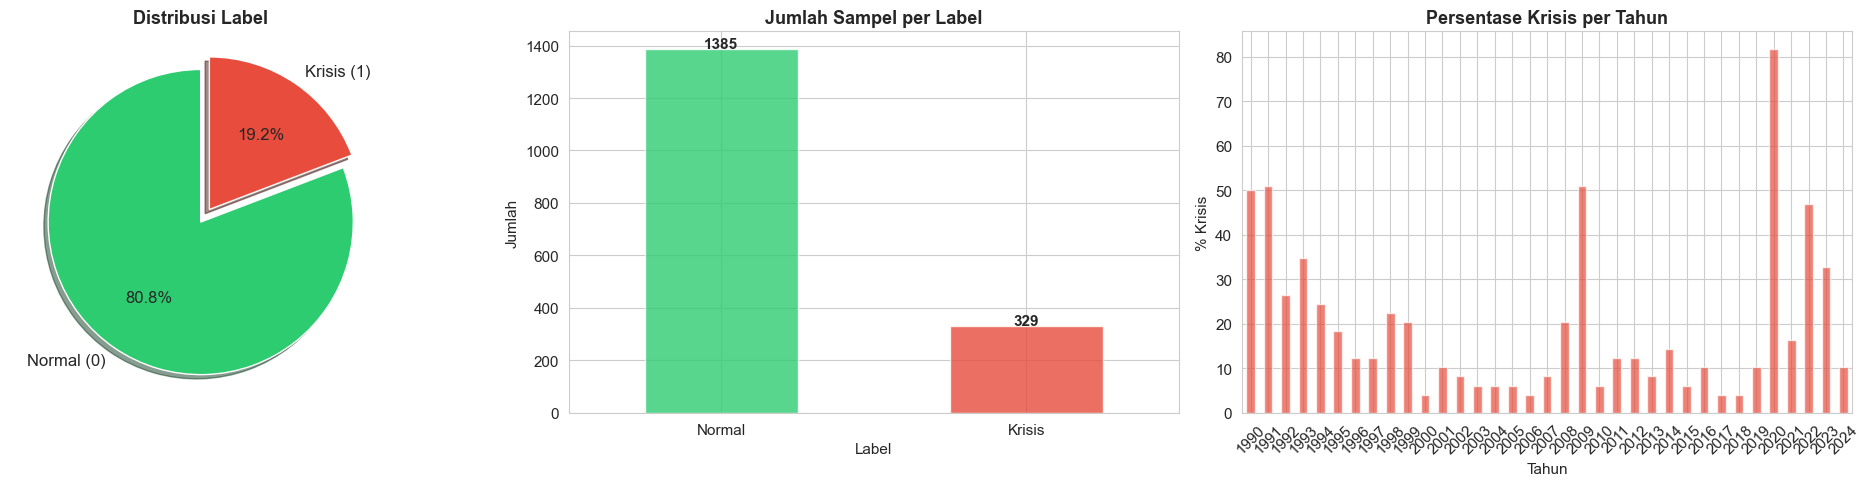

In [30]:
# Visualisasi distribusi label
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Pie chart
counts = df_clean['crisis_label'].value_counts()
colors = ['#2ecc71', '#e74c3c']
labels_pie = ['Normal (0)', 'Krisis (1)']
explode = [0, 0.1]
axes[0].pie(counts, explode=explode, labels=labels_pie, colors=colors,
            autopct='%1.1f%%', shadow=True, startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Distribusi Label', fontsize=13, fontweight='bold')

# Bar chart
counts.plot(kind='bar', ax=axes[1], color=colors, edgecolor='white', alpha=0.8)
axes[1].set_title('Jumlah Sampel per Label', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Jumlah')
axes[1].set_xticklabels(['Normal', 'Krisis'], rotation=0)
for i, v in enumerate(counts):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Distribusi krisis per tahun
crisis_by_year = df_clean.groupby(df_label['year'])['crisis_label'].mean() * 100
crisis_by_year.plot(kind='bar', ax=axes[2], color='#e74c3c', alpha=0.7, edgecolor='white')
axes[2].set_title('Persentase Krisis per Tahun', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Tahun')
axes[2].set_ylabel('% Krisis')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 6.2 Penanganan Ketidakseimbangan Data

Karena anomali/krisis umumnya **jarang terjadi** (imbalanced), kita menggunakan beberapa teknik:
1. **SMOTE** (Synthetic Minority Over-sampling Technique)
2. **ADASYN** (Adaptive Synthetic Sampling)

Kita bandingkan keduanya dan pilih yang terbaik.

In [31]:
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN
from collections import Counter

X = df_clean[feature_cols].values
y = df_clean['crisis_label'].values

print(f'Distribusi SEBELUM resampling: {Counter(y)}')
print(f'Rasio: 1:{Counter(y)[0]//max(Counter(y)[1],1)}')

Distribusi SEBELUM resampling: Counter({np.int64(0): 1385, np.int64(1): 329})
Rasio: 1:4


In [32]:
# --- SMOTE ---
smote = SMOTE(random_state=42, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X, y)
print(f'SMOTE: {Counter(y_smote)}')

# --- ADASYN ---
try:
    adasyn = ADASYN(random_state=42, n_neighbors=5)
    X_adasyn, y_adasyn = adasyn.fit_resample(X, y)
    print(f'ADASYN: {Counter(y_adasyn)}')
except Exception as e:
    print(f'ADASYN gagal (kemungkinan data sudah cukup seimbang): {e}')
    X_adasyn, y_adasyn = X_smote.copy(), y_smote.copy()

# --- SMOTE + ENN (Kombinasi) ---
try:
    smoteenn = SMOTEENN(random_state=42)
    X_smoteenn, y_smoteenn = smoteenn.fit_resample(X, y)
    print(f'SMOTE+ENN: {Counter(y_smoteenn)}')
except Exception as e:
    print(f'SMOTE+ENN gagal: {e}')
    X_smoteenn, y_smoteenn = X_smote.copy(), y_smote.copy()

SMOTE: Counter({np.int64(0): 1385, np.int64(1): 1385})
ADASYN: Counter({np.int64(1): 1403, np.int64(0): 1385})
SMOTE+ENN: Counter({np.int64(1): 1186, np.int64(0): 1017})


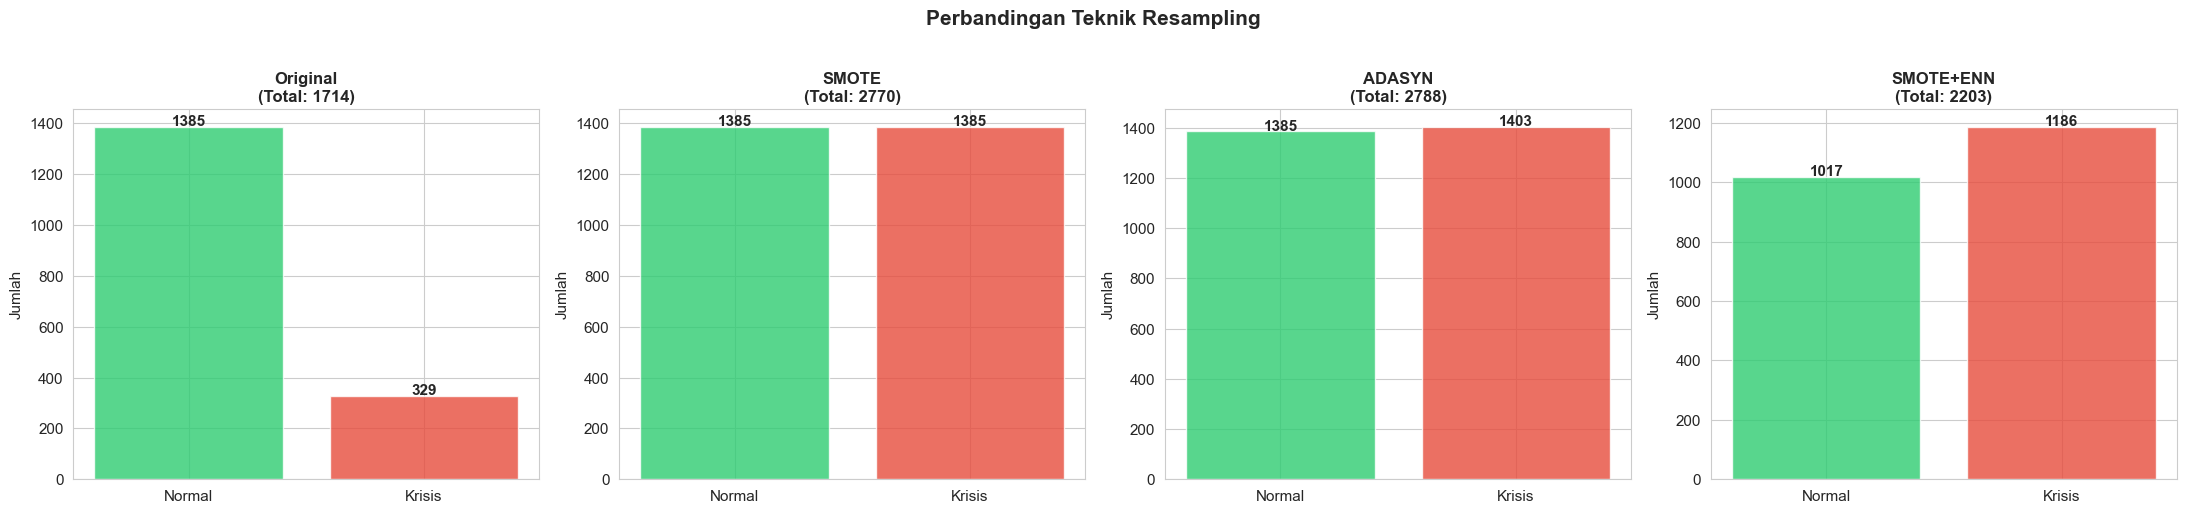

In [33]:
# Visualisasi perbandingan
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

datasets = [
    ('Original', Counter(y)),
    ('SMOTE', Counter(y_smote)),
    ('ADASYN', Counter(y_adasyn)),
    ('SMOTE+ENN', Counter(y_smoteenn))
]

colors = ['#2ecc71', '#e74c3c']

for i, (name, counter) in enumerate(datasets):
    values = [counter[0], counter[1]]
    bars = axes[i].bar(['Normal', 'Krisis'], values, color=colors, edgecolor='white', alpha=0.8)
    axes[i].set_title(f'{name}\n(Total: {sum(values)})', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Jumlah')
    for bar, v in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                     str(v), ha='center', fontweight='bold')

plt.suptitle('Perbandingan Teknik Resampling', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [34]:
# Pilih SMOTE sebagai metode resampling utama
# Alasan: paling stabil dan menghasilkan distribusi seimbang sempurna

df_resampled = pd.DataFrame(X_smote, columns=feature_cols)
df_resampled['crisis_label'] = y_smote

print(f'\n✅ Dataset setelah SMOTE:')
print(f'Shape: {df_resampled.shape}')
print(f'Distribusi: {Counter(y_smote)}')
print(f'Rasio: 1:1 (Seimbang)')


✅ Dataset setelah SMOTE:
Shape: (2770, 15)
Distribusi: Counter({np.int64(0): 1385, np.int64(1): 1385})
Rasio: 1:1 (Seimbang)


---
## 7. Analisis Korelasi

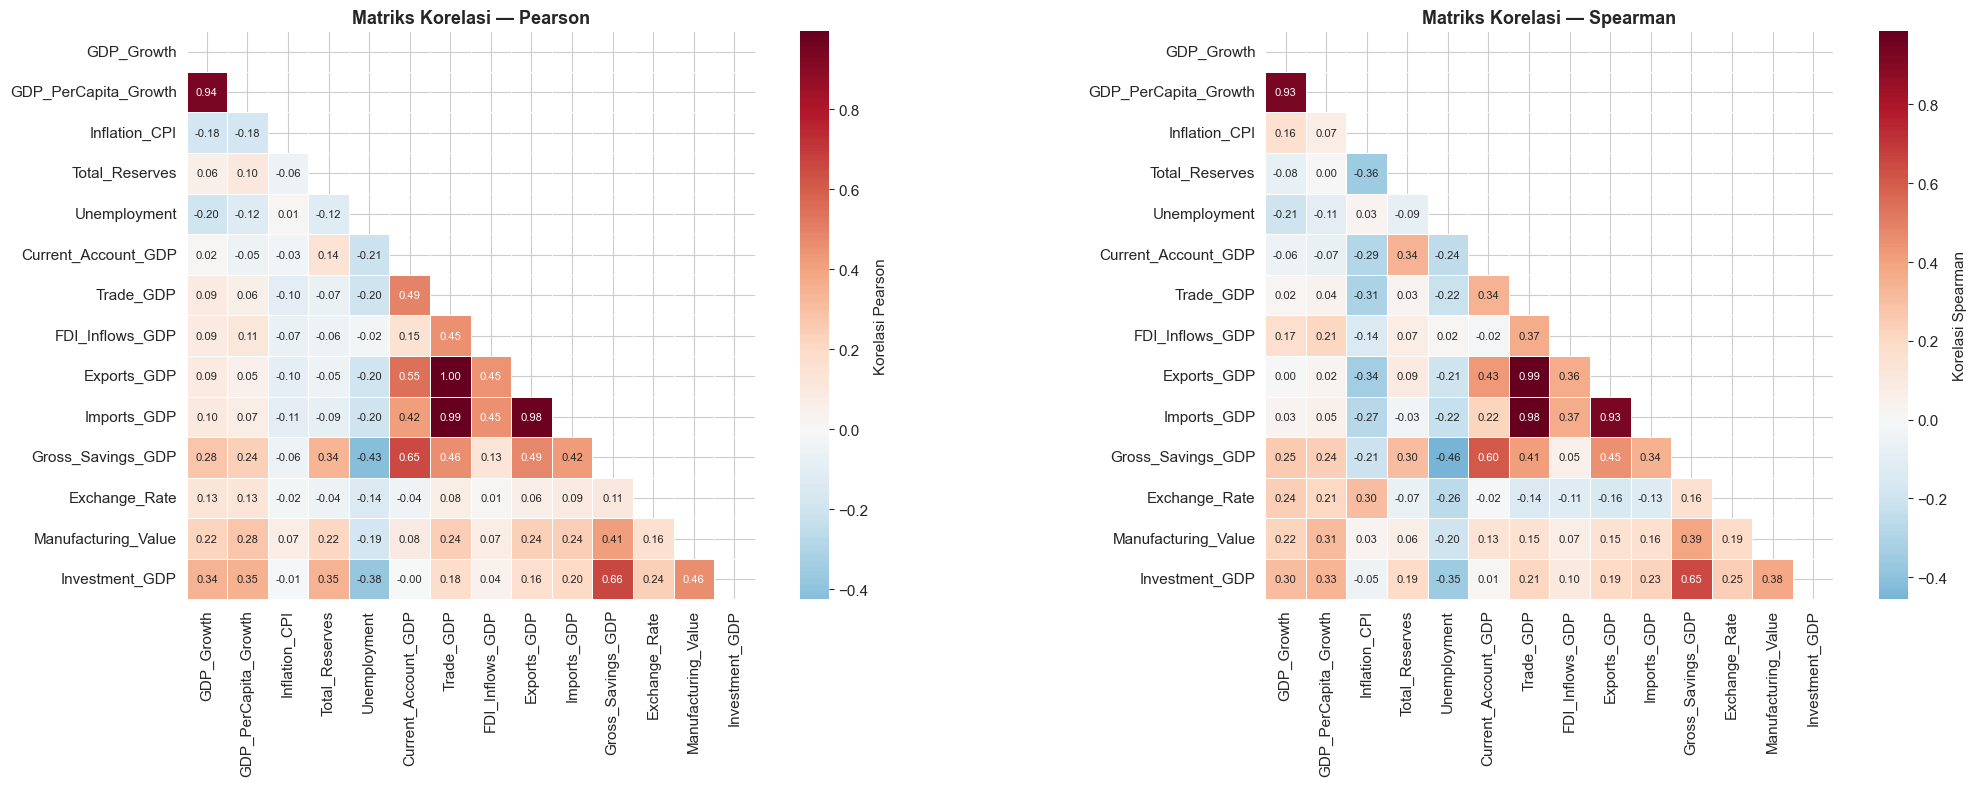

In [35]:
# Correlation Matrix
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# Pearson correlation
corr_matrix = df_clean[feature_cols].corr(method='pearson')
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=axes[0],
            cbar_kws={'label': 'Korelasi Pearson'},
            annot_kws={'fontsize': 8})
axes[0].set_title('Matriks Korelasi — Pearson', fontsize=13, fontweight='bold')

# Spearman correlation (lebih robust terhadap non-linearitas)
corr_spearman = df_clean[feature_cols].corr(method='spearman')
sns.heatmap(corr_spearman, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=axes[1],
            cbar_kws={'label': 'Korelasi Spearman'},
            annot_kws={'fontsize': 8})
axes[1].set_title('Matriks Korelasi — Spearman', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [36]:
# Identifikasi fitur yang berkorelasi tinggi (> 0.8)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append({
                'Fitur 1': corr_matrix.columns[i],
                'Fitur 2': corr_matrix.columns[j],
                'Korelasi': round(corr_matrix.iloc[i, j], 3)
            })

if high_corr_pairs:
    print('='*50)
    print('FITUR DENGAN KORELASI TINGGI (|r| > 0.8)')
    print('='*50)
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Korelasi', key=abs, ascending=False)
    print(high_corr_df.to_string(index=False))
    print(f'\n⚠️ {len(high_corr_pairs)} pasangan fitur memiliki korelasi tinggi.')
    print('Pertimbangkan untuk menghapus salah satu fitur atau menggunakan PCA.')
else:
    print('✅ Tidak ada pasangan fitur dengan korelasi > 0.8')

FITUR DENGAN KORELASI TINGGI (|r| > 0.8)
    Fitur 1              Fitur 2  Korelasi
  Trade_GDP          Exports_GDP     0.995
  Trade_GDP          Imports_GDP     0.993
Exports_GDP          Imports_GDP     0.978
 GDP_Growth GDP_PerCapita_Growth     0.943

⚠️ 4 pasangan fitur memiliki korelasi tinggi.
Pertimbangkan untuk menghapus salah satu fitur atau menggunakan PCA.


---
## 8. Ringkasan & Simpan Data Bersih

In [37]:
# Ringkasan preprocessing
print('='*60)
print('📊 RINGKASAN PREPROCESSING')
print('='*60)
print(f'\n1. DATA AWAL')
print(f'   Shape: {df.shape}')
print(f'   Missing values: {df.isnull().sum().sum()}')

print(f'\n2. DATA SETELAH PEMBERSIHAN (tanpa SMOTE)')
print(f'   Shape: {df_clean.shape}')
print(f'   Missing values: {df_clean[feature_cols].isnull().sum().sum()}')
print(f'   Metode missing value: Interpolasi Linear + KNN Imputer')
print(f'   Normalisasi: StandardScaler')
print(f'   Outlier: Winsorizing (cap 0.5%-99.5%)')

print(f'\n3. LABEL ANOMALI')
crisis_count = Counter(df_clean['crisis_label'].values)
print(f'   Normal: {crisis_count[0]} ({crisis_count[0]/len(df_clean)*100:.1f}%)')
print(f'   Krisis: {crisis_count[1]} ({crisis_count[1]/len(df_clean)*100:.1f}%)')

print(f'\n4. DATA SETELAH SMOTE')
print(f'   Shape: {df_resampled.shape}')
smote_count = Counter(df_resampled['crisis_label'].values)
print(f'   Normal: {smote_count[0]} ({smote_count[0]/len(df_resampled)*100:.1f}%)')
print(f'   Krisis: {smote_count[1]} ({smote_count[1]/len(df_resampled)*100:.1f}%)')

print(f'\n5. FITUR ({len(feature_cols)} fitur):')
for i, col in enumerate(feature_cols, 1):
    print(f'   {i:2d}. {col}')

print('\n' + '='*60)

📊 RINGKASAN PREPROCESSING

1. DATA AWAL
   Shape: (1715, 16)
   Missing values: 751

2. DATA SETELAH PEMBERSIHAN (tanpa SMOTE)
   Shape: (1714, 17)
   Missing values: 0
   Metode missing value: Interpolasi Linear + KNN Imputer
   Normalisasi: StandardScaler
   Outlier: Winsorizing (cap 0.5%-99.5%)

3. LABEL ANOMALI
   Normal: 1385 (80.8%)
   Krisis: 329 (19.2%)

4. DATA SETELAH SMOTE
   Shape: (2770, 15)
   Normal: 1385 (50.0%)
   Krisis: 1385 (50.0%)

5. FITUR (14 fitur):
    1. GDP_Growth
    2. GDP_PerCapita_Growth
    3. Inflation_CPI
    4. Total_Reserves
    5. Unemployment
    6. Current_Account_GDP
    7. Trade_GDP
    8. FDI_Inflows_GDP
    9. Exports_GDP
   10. Imports_GDP
   11. Gross_Savings_GDP
   12. Exchange_Rate
   13. Manufacturing_Value
   14. Investment_GDP



In [38]:
# Simpan dataset bersih

# 1. Data tanpa SMOTE (untuk unsupervised anomaly detection)
df_save = df_clean.copy()
df_save.to_csv('data_cleaned.csv', index=False)
print(f'✅ data_cleaned.csv disimpan ({df_save.shape})')

# 2. Data dengan SMOTE (untuk supervised / semi-supervised)
df_resampled.to_csv('data_cleaned_smote.csv', index=False)
print(f'✅ data_cleaned_smote.csv disimpan ({df_resampled.shape})')

# 3. Data label saja (tanpa scaling, untuk referensi)
df_label_save = df_label[['economy', 'year'] + feature_cols + ['crisis_label']].copy()
df_label_save.to_csv('data_with_labels.csv', index=False)
print(f'✅ data_with_labels.csv disimpan ({df_label_save.shape})')

✅ data_cleaned.csv disimpan ((1714, 17))
✅ data_cleaned_smote.csv disimpan ((2770, 15))
✅ data_with_labels.csv disimpan ((1714, 17))


In [39]:
# Preview data final
print('\n📋 Preview Data Bersih (tanpa SMOTE):')
df_clean.head(10)


📋 Preview Data Bersih (tanpa SMOTE):


,economy,year,GDP_Growth,GDP_PerCapita_Growth,Inflation_CPI,Total_Reserves,Unemployment,Current_Account_GDP,Trade_GDP,FDI_Inflows_GDP,Exports_GDP,Imports_GDP,Gross_Savings_GDP,Exchange_Rate,Manufacturing_Value,Investment_GDP,crisis_label
0,ARE,1990,2.690913,2.607447,-0.035597,-0.349079,-1.105892,2.12939,0.234573,-0.486899,0.326385,0.123081,1.10385,-0.224663,-1.589531,-0.270213,0
1,ARE,1991,-0.638363,-1.838101,-0.035597,-0.347005,-1.105892,2.12939,0.234573,-0.448764,0.326385,0.123081,1.10385,-0.224663,-1.601884,-0.270213,0
2,ARE,1992,0.032110,-1.108947,-0.035597,-0.346099,-1.087378,2.12939,0.234573,-0.422930,0.326385,0.123081,1.10385,-0.224663,-1.573871,-0.270213,0
3,ARE,1993,-0.530135,-1.574741,-0.035597,-0.344897,-1.047336,2.12939,0.234573,-0.356948,0.326385,0.123081,1.10385,-0.224663,-1.528502,-0.270213,0
4,ARE,1994,0.990307,-0.018863,-0.035597,-0.343393,-1.061760,2.12939,0.234573,-0.441240,0.326385,0.123081,1.10385,-0.224663,-1.747591,-0.270213,0
5,ARE,1995,0.934113,-0.019623,-0.035597,-0.341158,-1.069079,2.12939,0.234573,-0.372445,0.326385,0.123081,1.10385,-0.224663,-1.715364,-0.270213,0
6,ARE,1996,0.694110,-0.805975,-0.035597,-0.339589,-1.061329,2.12939,0.234573,-0.399767,0.326385,0.123081,1.10385,-0.224663,-1.738940,-0.270213,0
7,ARE,1997,1.339525,-0.645131,-0.035597,-0.338896,-1.046260,2.12939,0.234573,-0.415316,0.326385,0.123081,1.10385,-0.224663,-1.519481,-0.270213,0
8,ARE,1998,-0.791646,-2.519042,-0.035597,-0.336968,-1.011385,2.12939,0.234573,-0.409068,0.326385,0.123081,1.10385,-0.224662,-1.391178,-0.270213,0
9,ARE,1999,-0.087349,-1.732641,-0.035597,-0.332896,-0.984044,2.12939,0.234573,-0.615275,0.326385,0.123081,1.10385,-0.224662,-1.404015,-0.270213,0


In [40]:
# Preview data SMOTE
print('\n📋 Preview Data SMOTE:')
df_resampled.head(10)


📋 Preview Data SMOTE:


,GDP_Growth,GDP_PerCapita_Growth,Inflation_CPI,Total_Reserves,Unemployment,Current_Account_GDP,Trade_GDP,FDI_Inflows_GDP,Exports_GDP,Imports_GDP,Gross_Savings_GDP,Exchange_Rate,Manufacturing_Value,Investment_GDP,crisis_label
0,2.690913,2.607447,-0.035597,-0.349079,-1.105892,2.12939,0.234573,-0.486899,0.326385,0.123081,1.10385,-0.224663,-1.589531,-0.270213,0
1,-0.638363,-1.838101,-0.035597,-0.347005,-1.105892,2.12939,0.234573,-0.448764,0.326385,0.123081,1.10385,-0.224663,-1.601884,-0.270213,0
2,0.032110,-1.108947,-0.035597,-0.346099,-1.087378,2.12939,0.234573,-0.422930,0.326385,0.123081,1.10385,-0.224663,-1.573871,-0.270213,0
3,-0.530135,-1.574741,-0.035597,-0.344897,-1.047336,2.12939,0.234573,-0.356948,0.326385,0.123081,1.10385,-0.224663,-1.528502,-0.270213,0
4,0.990307,-0.018863,-0.035597,-0.343393,-1.061760,2.12939,0.234573,-0.441240,0.326385,0.123081,1.10385,-0.224663,-1.747591,-0.270213,0
5,0.934113,-0.019623,-0.035597,-0.341158,-1.069079,2.12939,0.234573,-0.372445,0.326385,0.123081,1.10385,-0.224663,-1.715364,-0.270213,0
6,0.694110,-0.805975,-0.035597,-0.339589,-1.061329,2.12939,0.234573,-0.399767,0.326385,0.123081,1.10385,-0.224663,-1.738940,-0.270213,0
7,1.339525,-0.645131,-0.035597,-0.338896,-1.046260,2.12939,0.234573,-0.415316,0.326385,0.123081,1.10385,-0.224663,-1.519481,-0.270213,0
8,-0.791646,-2.519042,-0.035597,-0.336968,-1.011385,2.12939,0.234573,-0.409068,0.326385,0.123081,1.10385,-0.224662,-1.391178,-0.270213,0
9,-0.087349,-1.732641,-0.035597,-0.332896,-0.984044,2.12939,0.234573,-0.615275,0.326385,0.123081,1.10385,-0.224662,-1.404015,-0.270213,0


---
## ✅ Kesimpulan Preprocessing

| Tahap | Metode | Alasan |
|-------|--------|--------|
| **Missing Value** | Interpolasi Linear + KNN Imputer | Data time-series → interpolasi temporal; KNN untuk pola antar fitur |
| **Normalisasi** | StandardScaler | Cocok untuk Isolation Forest, LOF, Autoencoder (mean=0, std=1) |
| **Outlier** | Winsorizing (0.5%-99.5%) | Pertahankan outlier krisis, hanya cap nilai sangat ekstrem |
| **Keseimbangan** | SMOTE | Mengatasi imbalanced class untuk evaluasi supervised |
| **Korelasi** | Pearson + Spearman | Identifikasi multikolinearitas |

**Output file:**
- `data_cleaned.csv` → Data bersih tanpa SMOTE (untuk unsupervised)
- `data_cleaned_smote.csv` → Data bersih dengan SMOTE (untuk supervised)
- `data_with_labels.csv` → Data dengan label tanpa scaling (referensi)